In [112]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from sklearn.neighbors import NearestNeighbors


### Упражнение 1

- Вычислить карту бифуркации системы Ресслера.
- Оставьте фиксированными параметры $a = b = 0.2$.
- Измените параметр $c$, как показано ниже.
- Для каждого значения $c$ вычислите и постройте локальные максимумы временного ряда $z(t)$, используя функцию `scipy.signal.find_peaks`. У вас должен получиться график, похожий на рисунок ниже.
- Определите первую точку бифуркации, прежде чем система станет хаотичной.
- Объясните, почему для логистической карты не требовалось вычисление локальных максимумов (пиков).

<img src="https://github.com/fmi-ml-courses/ts-magi-2025-2026/blob/main/data/l11/rossler_attractor.png?raw=1" style="width: 100%; display: block; margin: auto;">

In [114]:
# Define the Rössler attractor system of equations
def rossler_system(t, y, a, b, c):
    x, y, z = y
    dxdt = -y - z
    dydt = x + a*y
    dzdt = b + z*(x - c)
    return [dxdt, dydt, dzdt]

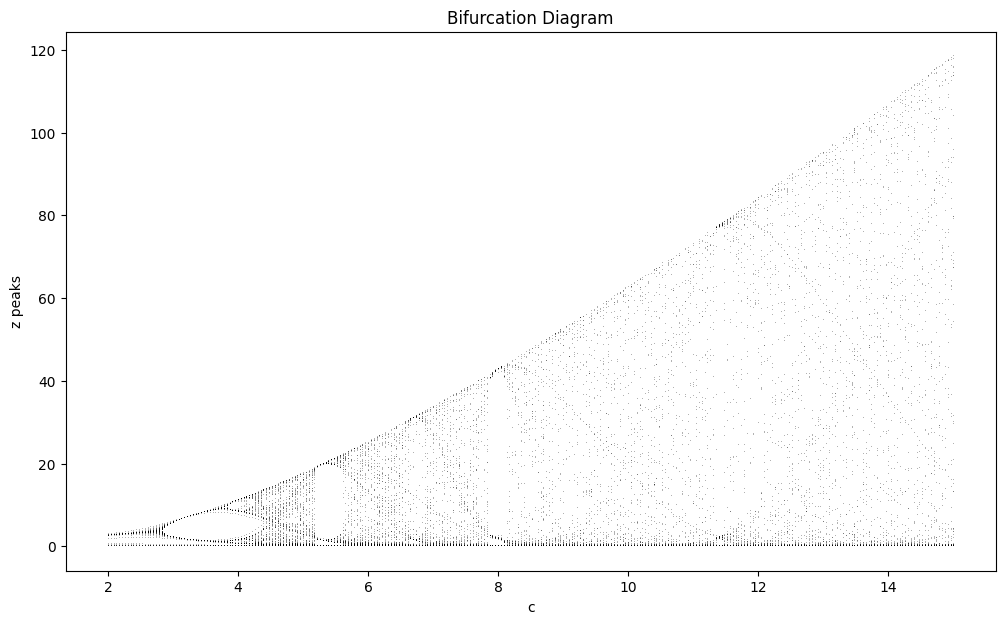

In [119]:
# Parameters
a, b, c_arr = 0.2, 0.2, np.linspace(2, 15, 300)

# c = np.linspace(2, 15, 300) # value of c to explore
y0 = [0.0, 0.0, 0.0]  # Initial conditions
T = 500 # Final time
t_span = [0, T]  # Time span for the integration
t = np.linspace(0, T, int(5e4))

fig, ax = plt.subplots(figsize=(12, 7))

for c in c_arr:
    # Решаем систему для конкретного c
    sol = solve_ivp(rossler_system, t_span, y0, args=(a, b, c), t_eval=t)
    z = sol.y[2]

    # Находим локальные максимумы (пики)
    peaks, _ = find_peaks(z)
    z_peaks = z[peaks]

    # Рисуем точки для данного c
    ax.plot([c] * len(z_peaks), z_peaks, ',k', alpha=0.3)

ax.set_title("Bifurcation Diagram")
ax.set_xlabel("c")
ax.set_ylabel("z peaks")
plt.show()

первая точка бифуркации в точке с = 2.6

Логистическая карта - это дискретное отображение. В этом случае временной ряд уже дискретный, каждое значение x_n является точкой отображения, достаточно построить значения x_n после переходного процесса в зависимости от параметра r.

### Упражнение 2

- Вычислите (фрактальную) размерность объекта, показанного на рисунке ниже.

<img src="https://github.com/fmi-ml-courses/ts-magi-2025-2026/blob/main/data/l11/menger-sr.jpeg?raw=1" style="width: 40%; display: block; margin: auto;">

In [24]:
def fractal_dimension(N, k):

    D = np.log(N) / np.log(k)

    print(f"Фрактальная размерность: D = {D:.4f}")
    print(f"  N = {N} частей")
    print(f"  k = {k} (масштаб 1/{k})")

    return D

In [25]:
D_sierpinski = fractal_dimension(N=27, k=3)

for i in range(1, 4):
    k = 3 ** i
    N = 20 ** i
    fractal_dimension(N=N, k=k)

Фрактальная размерность: D = 3.0000
  N = 27 частей
  k = 3 (масштаб 1/3)
Фрактальная размерность: D = 2.7268
  N = 20 частей
  k = 3 (масштаб 1/3)
Фрактальная размерность: D = 2.7268
  N = 400 частей
  k = 9 (масштаб 1/9)
Фрактальная размерность: D = 2.7268
  N = 8000 частей
  k = 27 (масштаб 1/27)


## Упражнение 3

- Постройте аттрактор Лоренца для $\sigma = 10$, $\rho = 28$ и $\beta = \frac{8}{3}$.

In [3]:
def lorenz(t, x, sigma, rho, beta):
    res = np.zeros_like(x)
    res[0] = sigma*(x[1] - x[0])
    res[1] = x[0]*(rho - x[2]) - x[1]
    res[2] = x[0]*x[1] - beta*x[2]
    return res

In [5]:
def plot_attractor(data, title="", interactive=False):
    xt, yt, zt = data[0], data[1], data[2]
    if interactive:
        fig = go.Figure(data=[go.Scatter3d(x=xt, y=yt, z=zt, mode='lines', line=dict(color='black', width=1))])
        fig.update_layout(title=title, scene=dict(xaxis_title='x(t)', yaxis_title='y(t)', zaxis_title='z(t)'),
                          autosize=False, width=800, height=600, margin=dict(l=0, r=0, b=0, t=0))
        fig.show()
    else:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(xt, yt, zt, linewidth=0.2, alpha=0.7, color='k')
        ax.set_title(title)
        plt.show()

In [24]:
x0 = np.array([1.5, -1.5, 20.])
T = 500 # Final time
t_span = [0, T]
sigma, rho, beta = 10., 28., 8/3

solution = solve_ivp(lorenz, t_span, x0, args=(sigma, rho, beta), dense_output=True)
t = np.linspace(0, T, int(5e4))
lorenz_sol = solution.sol(t)


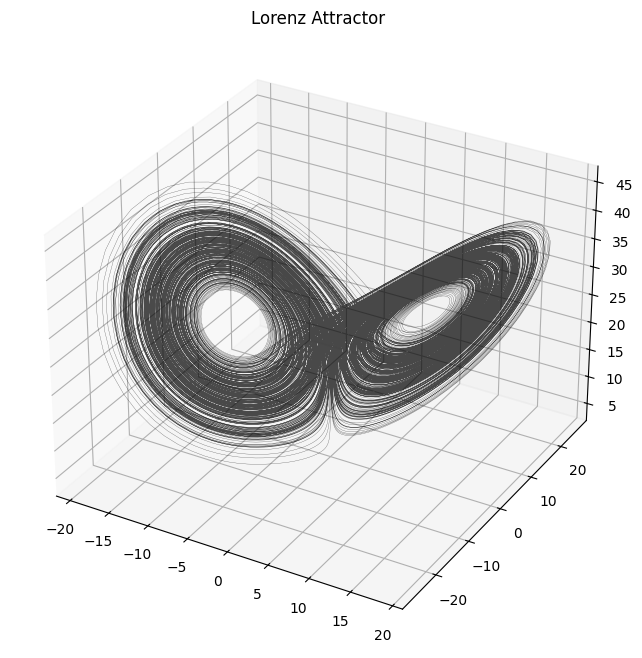

In [25]:
plot_attractor(lorenz_sol, title="Lorenz Attractor", interactive=False)

### Упражнение 4

- Используйте вложение Taken, чтобы восстановить аттрактор Лоренца по временному ряду его первой переменной состояния $x(t)$.
- Вычислите оптимальную временную задержку $\tau$ и оптимальную размерность вложения $m$, используя алгоритмы взаимной информации и ложных ближайших соседей.

In [26]:
def takens_embedding(data, delay, dimension):
    embedding = np.array([data[0:len(data)-delay*dimension]])
    for i in range(1, dimension):
        embedding = np.append(embedding, [data[i*delay:len(data) - delay*(dimension - i)]], axis=0)
    return embedding.transpose()

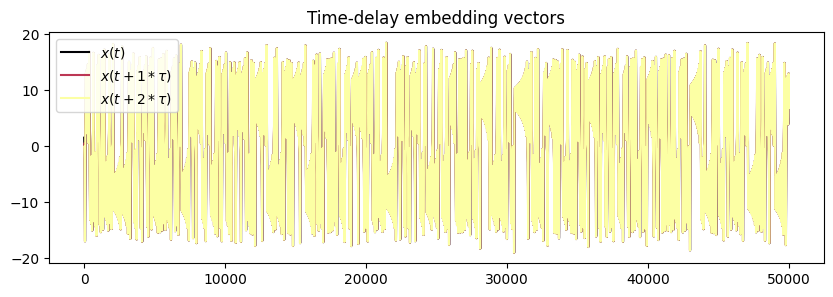

In [37]:
t = np.linspace(0, 10*np.pi, 100)
x = lorenz_sol[0]
tau = 5
N = 3                              # embedding dimension
emb = takens_embedding(x, tau, N)  # compute embeddings

cmap = plt.get_cmap('inferno')
fig, ax = plt.subplots(1,1, figsize=(10,3))
for i in range(N):
    _label = f"$x(t + {i}*\\tau )$" if i > 0 else f'$x(t)$'
    ax.plot(emb[:,i], label=_label, color=cmap(i / (N - 1)))
plt.legend()
plt.title('Time-delay embedding vectors')
plt.show()

In [38]:
def mutual_information(data, delay, n_bins):
    """
    Calculate the mutual information for a given delay using histograms.
    """
    # Prepare delayed data
    delayed_data = data[delay:]
    original_data = data[:-delay]

    # Compute histograms
    p_x, bin_edges = np.histogram(original_data, bins=n_bins, density=True)
    p_y, _ = np.histogram(delayed_data, bins=bin_edges, density=True)
    p_xy, _, _ = np.histogram2d(original_data, delayed_data, bins=bin_edges, density=True)

    # Calculate mutual information
    mutual_info = 0
    for i in range(n_bins):
        for j in range(n_bins):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mutual_info += p_xy[i, j] * np.log(p_xy[i, j] / (p_x[i] * p_y[j]))

    return mutual_info

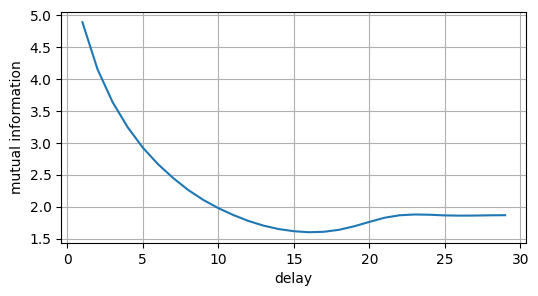

In [44]:
MI = []
for i in range(1,30):
    MI = np.append(MI,[mutual_information(lorenz_sol[0],i,50)])
plt.figure(figsize=(6,3))
plt.plot(range(1,30), MI)
plt.xlabel('delay')
plt.ylabel('mutual information')
plt.grid()
plt.show()

- Видим, что оптимальное значение $\tau$ составляет $16$.

In [49]:
def calculate_fnn(data, delay, max_emb_dim, R_tol=10):
    fnn_proportions = []
    for m in range(1, max_emb_dim + 1):

        # Compute embeddings in m and m+1
        emb_m = takens_embedding(data, delay, m)
        emb_m_plus_one = takens_embedding(data, delay, m + 1)

        # Compute the nearest neighbors in m
        nbrs = NearestNeighbors(n_neighbors=2).fit(emb_m[:-delay])
        distances, indices = nbrs.kneighbors(emb_m[:-delay])

        n_false_nn = 0
        for i in range(0, len(distances)):

            # Nearest neighbor of i in m and distance from it
            neighbor_index, R_m = indices[i, 1], distances[i, 1]

            # Dinstance in m+1 from the nearest neighbor in m
            R_m_plus_one = np.linalg.norm(emb_m_plus_one[i] - emb_m_plus_one[neighbor_index])

            # fNN formula
            if abs(R_m_plus_one - R_m) / R_m > R_tol:
                n_false_nn += 1

        fnn_proportion = n_false_nn / len(indices)
        fnn_proportions.append(fnn_proportion)

    return fnn_proportions

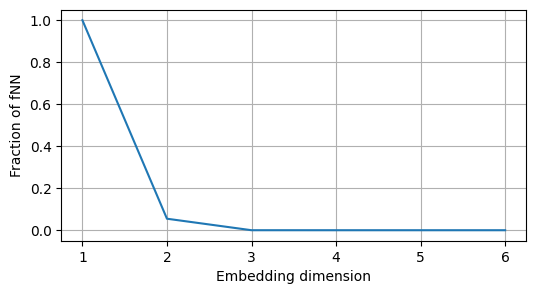

In [52]:
nFNN = calculate_fnn(lorenz_sol[0], delay=5, max_emb_dim=6)

plt.figure(figsize=(6,3))
plt.plot(range(1,len(nFNN)+1),nFNN)
plt.xlabel('Embedding dimension')
plt.ylabel('Fraction of fNN')
plt.grid()
plt.show()

* Видим, доля fNN падает до нуля при $m=3$.

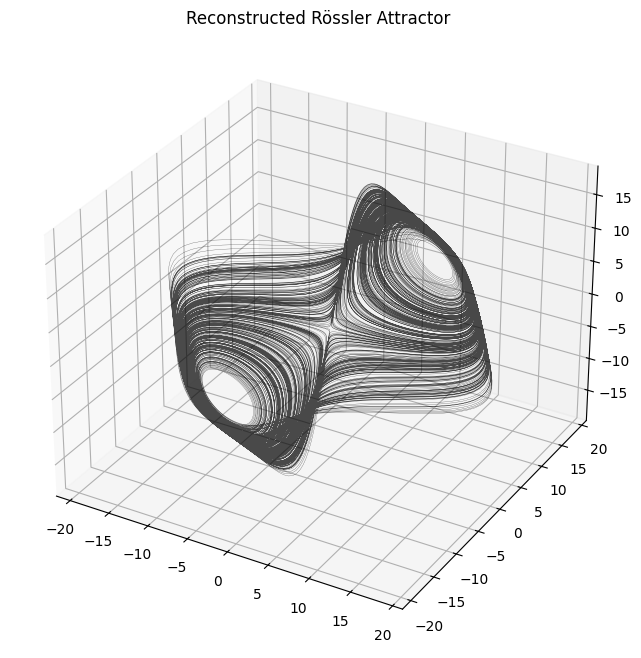

In [53]:
emb = takens_embedding(lorenz_sol[0], delay=16, dimension=3)
plot_attractor(emb.T, title="Reconstructed Lorenz Attractor", interactive=False)

Реконструированный аттрактор диффеоморфен исходному. (топологически эквивалентен)


### Упражнение 5

- Вычислите прогнозы переменной состояния $x(t)$ системы Лоренца, используя вложения задержки Taken и алгоритм регрессии по вашему выбору (регрессия Риджа, случайный лес и т. д.).

In [57]:
lorenz_sol.shape

(3, 50000)

In [65]:
emb.shape

(49985, 3)

In [79]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [68]:
y = lorenz_sol[0][:emb.shape[0]]

In [72]:
X_train, y_train = emb[:int(len(y)*0.8)], y[:int(len(y)*0.8)]
X_test, y_test = emb[int(len(y)*0.8):], y[int(len(y)*0.8):]

In [73]:
ridge = Ridge()
ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [74]:
pred = ridge.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [75]:
pred

array([11.11669278, 10.81494318, 10.47998459, ..., 12.45850727,
       12.15600038, 11.79312254])

In [78]:
print({
    'r2_score': r2_score(y_test, pred),
    'mean_squared_error': mean_squared_error(y_test, pred),
    'mean_absolute_error': mean_absolute_error(y_test, pred)
})

{'r2_score': 0.9999999999901571, 'mean_squared_error': 6.208780630391062e-10, 'mean_absolute_error': 2.012138742466292e-05}


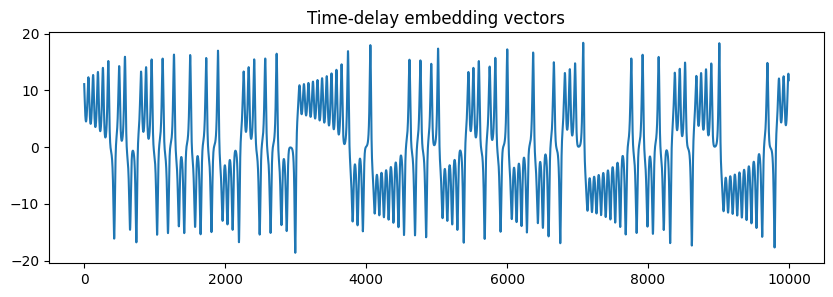

In [86]:
t = np.linspace(0, 10*np.pi, 100)
cmap = plt.get_cmap('inferno')
fig, ax = plt.subplots(1,1, figsize=(10,3))

ax.plot(pred, label=_label)
plt.title('Time-delay embedding vectors')
plt.show()

### Упражнение 6

- Вычислите прогнозы переменной состояния $x(t)$ системы Лоренца с помощью ESN, используя горизонт прогнозирования по вашему выбору.
- Создайте трехмерный график состояний Резервуара, уменьшенный до трех измерений с помощью PCA, и сравните его с реальным аттрактором Лоренца.

In [103]:
from sklearn.decomposition import PCA
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.utils import make_forecasting_dataset
from sklearn.ensemble import RandomForestRegressor

In [100]:
Xtr, Ytr, Xte, Yte, scaler = make_forecasting_dataset(lorenz_sol[0][:,None],
                                                  horizon=16,
                                                  test_percent = 0.1)
print(f"Xtr shape: {Xtr.shape}\nYtr shape: {Ytr.shape}\nXte shape: {Xte.shape}\nYte shape: {Yte.shape}")

Xtr shape: (44984, 2)
Ytr shape: (44984, 1)
Xte shape: (4984, 2)
Yte shape: (4984, 1)


In [101]:
res= Reservoir(n_internal_units=900,
               spectral_radius=0.99,
               input_scaling=0.1,
               connectivity=0.25)

n_drop=10
states_tr = res.get_states(Xtr[None,:,:], n_drop=n_drop, bidir=False)
states_te = res.get_states(Xte[None,:,:], n_drop=n_drop, bidir=False)
print(f"states_tr shape: {states_tr.shape}\nstates_te shape: {states_te.shape}")

states_tr shape: (1, 44974, 900)
states_te shape: (1, 4974, 900)


In [104]:
pca = PCA(n_components=3)
states_tr_pca = pca.fit_transform(states_tr[0])
states_te_pca = pca.transform(states_te[0])
print(f"states_tr shape: {states_tr_pca.shape}\nstates_te shape: {states_te_pca.shape}")

states_tr shape: (44974, 3)
states_te shape: (4974, 3)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

In [106]:
# Fit the regression model
rf = RandomForestRegressor().fit(states_tr_pca, Ytr[n_drop:,:].ravel())

# Compute the predictions
Yhat_pca = rf.predict(states_te_pca)[...,None]

# Compute the mean squared error
mse = mean_squared_error(scaler.inverse_transform(Yhat_pca), Yte[n_drop:,:])
print(f"MSE: {mse:.2f}")

MSE: 0.04


In [107]:
Yhat_pca

array([[0.41476277],
       [0.37712904],
       [0.34251982],
       ...,
       [0.73298963],
       [0.67468353],
       [0.63607765]])

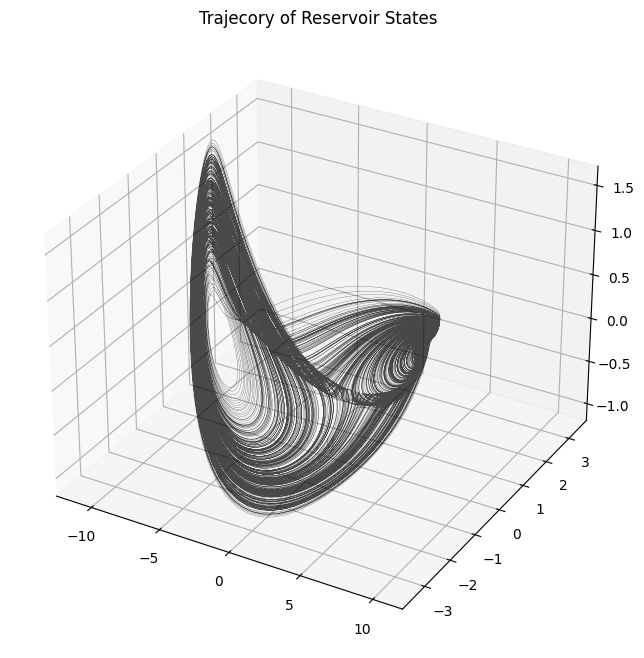

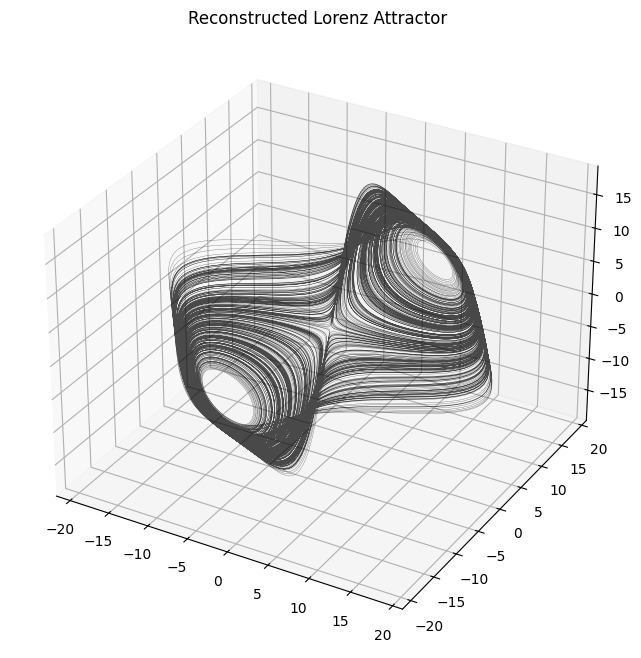

In [111]:
plot_attractor(states_tr_pca.T, title="Trajecory of Reservoir States", interactive=False)

emb = takens_embedding(lorenz_sol[0], delay=16, dimension=3)
plot_attractor(emb.T, title="Reconstructed Lorenz Attractor", interactive=False)